# 0 - Set-Up

In [1]:
# Install required packages
!pip install -qq -r ../requirements.txt

# Set up root directory
import sys

REL_PATH_TO_ROOT = "../"

sys.path.insert(0,REL_PATH_TO_ROOT)

from src.utils import get_root_dir, test_root_dir
from local_variables import ROOT_DIR

test_root_dir(REL_PATH_TO_ROOT)

Root directory set up correctly!


## Import Packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import project_tests as t
import pickle 

Root directory set up correctly!


## Import Data

In [3]:
df = pd.read_csv(f'{get_root_dir()}/data/user-item-interactions.csv',index_col=0)
df_content = pd.read_csv(f'{get_root_dir()}/data/articles_community.csv',index_col=0)

In [4]:
df.head()

,article_id,title,email
0,1430.0,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1314.0,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,1429.0,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,1338.0,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,1276.0,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


In [5]:
df_content.head()

,doc_body,doc_description,doc_full_name,doc_status,article_id
3,Skip navigation Sign in SearchLoading...\r\n\r...,Detect bad readings in real time using Python ...,Detect Malfunctioning IoT Sensors with Streami...,Live,0
5,No Free Hunch Navigation * kaggle.com\r\n\r\n ...,"See the forest, see the trees. Here lies the c...",Communicating data science: A guide to present...,Live,1
7,☰ * Login\r\n * Sign Up\r\n\r\n * Learning Pat...,Here’s this week’s news in Data Science and Bi...,"This Week in Data Science (April 18, 2017)",Live,2
8,"DATALAYER: HIGH THROUGHPUT, LOW LATENCY AT SCA...",Learn how distributed DBs solve the problem of...,DataLayer Conference: Boost the performance of...,Live,3
12,Skip navigation Sign in SearchLoading...\r\n\r...,This video demonstrates the power of IBM DataS...,Analyze NY Restaurant data using Spark in DSX,Live,4


## Table of Contents

I. Exploratory Data Analysis  
II. Rank Based Recommendations  
III. User-User Based Collaborative Filtering  
IV. Content Based Recommendations (EXTRA - NOT REQUIRED)  
V. Matrix Factorization  
VI. Extras & Concluding  

# Part I : Exploratory Data Analysis

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.



## `1.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.  

(0.0, 937.0)

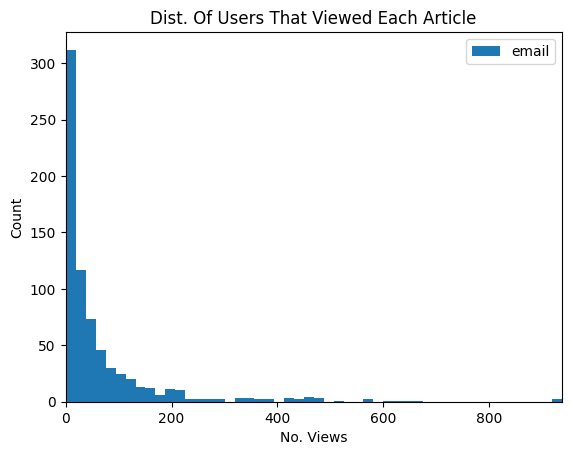

In [6]:
# Step 1: Views per article 

article_view_counts = df[["article_id","email"]].groupby(by="article_id").agg("count")

ax = article_view_counts.plot(kind="hist",bins=50)
ax.set_title("Dist. of users that viewed each article".title())
ax.set_xlabel("No. Views")
ax.set_ylabel("Count")
ax.set_xlim([0,article_view_counts["email"].max()])

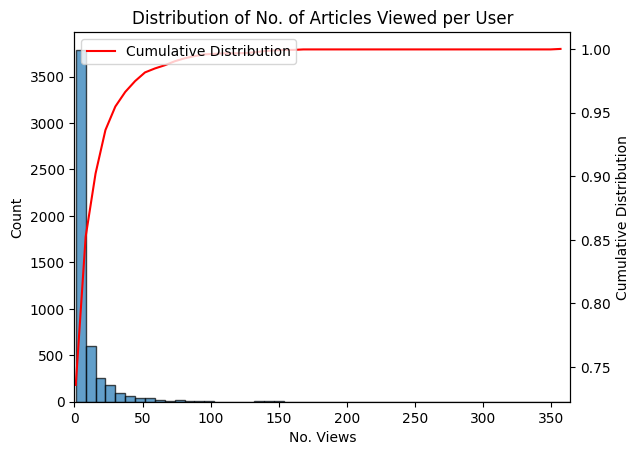

In [7]:
# Step 2 : View article interactions per user

user_view_counts = df[["email", "article_id"]].groupby(by="email").agg("count")

# Histogram data
hist_values, bin_edges = np.histogram(user_view_counts["article_id"], bins=50)
cumulative = np.cumsum(hist_values) / np.sum(hist_values)  # Compute cumulative distribution

# Plot the histogram
fig, ax1 = plt.subplots()
ax1.hist(user_view_counts["article_id"], bins=50, alpha=0.7, edgecolor='black', label='Histogram')
ax1.set_title("Distribution of No. of Articles Viewed per User")
ax1.set_xlabel("No. Views")
ax1.set_ylabel("Count")
ax1.set_xlim([0, user_view_counts["article_id"].max()])

# Add cumulative distribution
ax2 = ax1.twinx()
ax2.plot(bin_edges[:-1], cumulative, color="red", label="Cumulative Distribution")
ax2.set_ylabel("Cumulative Distribution")
ax2.legend(loc="upper left")

plt.show()

In [8]:
np.cumsum([1,2,3,4])

array([ 1,  3,  6, 10])

Seems to be a poisson/exponential distribution, with most users only viewing a smaller number of articles and a minority of users viewing a large number of articles

In [9]:
# Step 3 : Look at descriptive statistics
median_val = user_view_counts["article_id"].median()
max_views_by_user = user_view_counts["article_id"].max()

print(median_val, max_views_by_user)

3.0 364


## `2.` Explore and remove duplicate articles from the **df_content** dataframe.  

In [10]:
# Check df_content
df_content.head()

,doc_body,doc_description,doc_full_name,doc_status,article_id
3,Skip navigation Sign in SearchLoading...\r\n\r...,Detect bad readings in real time using Python ...,Detect Malfunctioning IoT Sensors with Streami...,Live,0
5,No Free Hunch Navigation * kaggle.com\r\n\r\n ...,"See the forest, see the trees. Here lies the c...",Communicating data science: A guide to present...,Live,1
7,☰ * Login\r\n * Sign Up\r\n\r\n * Learning Pat...,Here’s this week’s news in Data Science and Bi...,"This Week in Data Science (April 18, 2017)",Live,2
8,"DATALAYER: HIGH THROUGHPUT, LOW LATENCY AT SCA...",Learn how distributed DBs solve the problem of...,DataLayer Conference: Boost the performance of...,Live,3
12,Skip navigation Sign in SearchLoading...\r\n\r...,This video demonstrates the power of IBM DataS...,Analyze NY Restaurant data using Spark in DSX,Live,4


In [11]:
# How many rows refer to duplicate article IDs?
df_content["article_id"].value_counts().reset_index()["count"].value_counts()

count
1    1046
2       5
Name: count, dtype: int64

5 Duplicate Article IDs, let's select for them and see

In [12]:
# Get counts for each article id in the DataFrame
article_counts = df_content["article_id"].value_counts().reset_index()

# Select article IDs where the count is greater than 1 (i.e. not unique)
duplicated_articles = df_content[df_content["article_id"].isin(article_counts[article_counts["count"]>1]["article_id"].unique())]

# Show these articles (should only be 20)
duplicated_articles.sort_values(by="article_id").head(20)

,doc_body,doc_description,doc_full_name,doc_status,article_id
129,Follow Sign in / Sign up Home About Insight Da...,Community Detection at Scale,Graph-based machine learning,Live,50
1103,Follow Sign in / Sign up Home About Insight Da...,During the seven-week Insight Data Engineering...,Graph-based machine learning,Live,50
623,* United States\r\n\r\nIBM® * Site map\r\n\r\n...,When used to make sense of huge amounts of con...,How smart catalogs can turn the big data flood...,Live,221
2123,Homepage Follow Sign in / Sign up Homepage * H...,One of the earliest documented catalogs was co...,How smart catalogs can turn the big data flood...,Live,221
672,Homepage Follow Sign in Get started Homepage *...,"If you are like most data scientists, you are ...",Self-service data preparation with IBM Data Re...,Live,232
3017,Homepage Follow Sign in Get started * Home\r\n...,"If you are like most data scientists, you are ...",Self-service data preparation with IBM Data Re...,Live,232
2324,Homepage Follow Sign in Get started Homepage *...,Today’s world of data science leverages data f...,Using Apache Spark as a parallel processing fr...,Live,398
1186,Homepage Follow Sign in Get started * Home\r\n...,Today’s world of data science leverages data f...,Using Apache Spark as a parallel processing fr...,Live,398
1803,This video shows you how to construct queries ...,This video shows you how to construct queries ...,Use the Primary Index,Live,577
3016,This video shows you how to construct queries ...,This video shows you how to construct queries ...,Use the Primary Index,Live,577


In [13]:
# Clean up body, description and full name 
for col in ["doc_body","doc_description","doc_full_name"]:
    duplicated_articles[col] = duplicated_articles[col].apply(lambda x : x.strip().lower())

/tmp/ipykernel_5152/1047042594.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplicated_articles[col] = duplicated_articles[col].apply(lambda x : x.strip().lower())


In [14]:
# Are these all really duplicates? Can we compare the doc field values
duplicated_articles.drop_duplicates().head(10).sort_values(by="article_id")

,doc_body,doc_description,doc_full_name,doc_status,article_id
129,follow sign in / sign up home about insight da...,community detection at scale,graph-based machine learning,Live,50
1103,follow sign in / sign up home about insight da...,during the seven-week insight data engineering...,graph-based machine learning,Live,50
623,* united states\r\n\r\nibm® * site map\r\n\r\n...,when used to make sense of huge amounts of con...,how smart catalogs can turn the big data flood...,Live,221
2123,homepage follow sign in / sign up homepage * h...,one of the earliest documented catalogs was co...,how smart catalogs can turn the big data flood...,Live,221
672,homepage follow sign in get started homepage *...,"if you are like most data scientists, you are ...",self-service data preparation with ibm data re...,Live,232
3017,homepage follow sign in get started * home\r\n...,"if you are like most data scientists, you are ...",self-service data preparation with ibm data re...,Live,232
2324,homepage follow sign in get started homepage *...,today’s world of data science leverages data f...,using apache spark as a parallel processing fr...,Live,398
1186,homepage follow sign in get started * home\r\n...,today’s world of data science leverages data f...,using apache spark as a parallel processing fr...,Live,398
1803,this video shows you how to construct queries ...,this video shows you how to construct queries ...,use the primary index,Live,577
3016,this video shows you how to construct queries ...,this video shows you how to construct queries ...,use the primary index,Live,577


None seem to be exactly duplicates

(Not printing due to size) The heads of the articles seem to differ, we are instructed in the original notebook to just take the first row

In [15]:
df_content = df_content.sort_index(ascending=True).drop_duplicates(subset="article_id", keep="first")

## `3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [16]:
unique_articles = df["article_id"].nunique()
total_articles = df_content["article_id"].nunique()
unique_users = df["email"].nunique()
user_article_interactions = len(df)

In [17]:
print(unique_articles, total_articles, unique_users, user_article_interactions)

714 1051 5148 45993


## `4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  

After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [18]:
most_viewed_article_id = str(article_view_counts.reset_index().sort_values(by="email",ascending=False)["article_id"].iloc[0])
max_views = article_view_counts.reset_index().sort_values(by="email",ascending=False)["email"].iloc[0]

In [19]:
print(most_viewed_article_id, max_views)

1429.0 937


In [20]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


In [21]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper():
    coded_dict = dict()
    cter = 1
    email_encoded = []
    
    for val in df['email']:
        if val not in coded_dict:
            coded_dict[val] = cter
            cter+=1
        
        email_encoded.append(coded_dict[val])
    return email_encoded

email_encoded = email_mapper()
del df['email']
df['user_id'] = email_encoded

# show header
df.head()

,article_id,title,user_id
0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1314.0,healthcare python streaming application demo,2
2,1429.0,use deep learning for image classification,3
3,1338.0,ml optimization using cognitive assistant,4
4,1276.0,deploy your python model as a restful api,5


# Part II: Rank-Based Recommendations

Unlike in the earlier lessons, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article.  In these cases, the popularity of an article can really only be based on how often an article was interacted with.

## `1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. 

Test your function using the tests below.

In [22]:
def get_top_articles(n, df=df):
    '''
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    '''
    # Your code here
    article_ids = get_top_article_ids(n,df=df)

    top_articles = list(df[df["article_id"].isin(article_ids)]["title"].unique())
    
    return top_articles # Return the top article titles from df (not df_content)

def get_top_article_ids(n, df=df):
    '''
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    '''
    # Your code here
    article_counts = df[["article_id","user_id"]].groupby(by="article_id",as_index=False).agg("count").sort_values(by="user_id",ascending=False)

    top_articles = article_counts.head(n)["article_id"].to_list()
    
    return top_articles # Return the top article ids

In [23]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['healthcare python streaming application demo', 'use deep learning for image classification', 'apache spark lab, part 1: basic concepts', 'predicting churn with the spss random tree algorithm', 'analyze energy consumption in buildings', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'gosales transactions for logistic regression model', 'insights from new york car accident reports', 'finding optimal locations of new store using decision optimization']
[1429.0, 1330.0, 1431.0, 1427.0, 1364.0, 1314.0, 1293.0, 1170.0, 1162.0, 1304.0]


In [24]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


# Part III: User-User Based Collaborative Filtering

## `1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [25]:
# create the user-article matrix with 1's and 0's
def create_user_item_matrix(df):
    '''
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    '''
    # Fill in the function here
    user_item = df.groupby(['user_id', 'article_id'])['article_id'].count().unstack(fill_value=0)
    user_item = user_item.applymap(lambda x: 1 if x > 0 else 0)
    
    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

/tmp/ipykernel_5152/3622206896.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  user_item = user_item.applymap(lambda x: 1 if x > 0 else 0)


In [26]:
user_item.shape

(5149, 714)

In [27]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


## `2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  

The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [28]:
def find_similar_users(user_id, user_item=user_item):
    '''
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered
    
    '''
    # compute similarity of each user to the provided user

    # Refer to provided user as 'central user'
    central_user_row = user_item.loc[user_id]

    non_central_users = user_item.drop(index=user_id)

    similarities = []
    row_ids = []
    
    for row_id in non_central_users.index:
        dot_score = np.dot(central_user_row,non_central_users.loc[row_id])
        similarities.append(dot_score)
        row_ids.append(row_id)

    # sort by similarity
    simil_df = pd.DataFrame({"user_id": row_ids, "similarity" : similarities})

    # create list of just the ids
    simil_df = simil_df.sort_values(by="similarity",ascending=False)
   
    # remove the own user's id
    most_similar_users = simil_df["user_id"].to_list()
       
    return most_similar_users # return a list of the users in order from most to least similar
        

In [29]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 3782, 23, 4459, 203, 131, 3870, 46, 4201, 5041]
The 5 most similar users to user 3933 are: [1, 23, 3782, 203, 4459]
The 3 most similar users to user 46 are: [4201, 23, 3782]


## `3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [30]:
def get_article_names(article_ids, df=df):
    '''
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column)
    '''
    # Your code here
    article_names = df[df["article_id"].astype(str).isin(article_ids)]["title"].unique()
    
    return article_names # Return the article names associated with list of article ids


def get_user_articles(user_id, user_item=user_item):
    '''
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the doc_full_name column in df_content)
    
    Description:
    Provides a list of the article_ids and article titles that have been seen by a user
    '''
    # Your code here
    article_views = user_item.loc[user_id].reset_index()
    article_views.columns = ["article_id","view_bool"]

    article_ids = article_views[article_views["view_bool"]>0]["article_id"].astype(str).unique()
    article_names = get_article_names(article_ids)
    
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    '''
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    '''
    # Your code here

    # Counter for while loop
    counter = 0 

    # Empty list for recommendations
    recs = [] 

    # Get list of most similar users (in order)
    most_similar_users = find_similar_users(user_id)

    # Create a set of articles that the user in question has already seen
    seen_articles = set(get_user_articles(user_id)[0])

    # While we still have recommendations to fill (counter<m)
    while counter < m:
        # Loop through most similar users in order
        for user in most_similar_users:
            # Get articles seen by those similar users as a set
            user_seen_articles = set(get_user_articles(user)[0])

            # Use the difference to find articles as yet unseen by the recomendee
            new_articles = seen_articles.difference(user_seen_articles)

            # Loop through these new articles adding them to the recommendations
            for article in new_articles:
                # Add rec
                recs.append(article)

                # Update counter for while loop
                counter+=1

                # Crucially we don't want to recommend the same article twice!
                seen_articles.add(article)

                # This indicates that we have found at least one recommendation, if this never gets set to True we can't recommend and need to break the loop
                rec_discovered = True

                # Break the loop (for articles)
                if counter >=m:
                    break

            # Break the loop (for users)
            if counter >=m:
                break

        # Break the loop if no recommendations could be found (i.e. user has seen them all)
        if rec_discovered == False:
            break
            
    
    return recs # return your recommendations for this user_id    

In [31]:
# Check Results
user_user_recs(1, 10) # Return 10 recommendations for user 1

['151.0',
 '151.0',
 '494.0',
 '585.0',
 '768.0',
 '1400.0',
 '346.0',
 '1406.0',
 '1363.0',
 '390.0']

In [32]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names(['1024.0', '1176.0', '1305.0', '1314.0', '1422.0', '1427.0'])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names(['1320.0', '232.0', '844.0'])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set(['1320.0', '232.0', '844.0'])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set(['1024.0', '1176.0', '1305.0', '1314.0', '1422.0', '1427.0'])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


## `4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [33]:
def get_top_sorted_users(user_id, df=df, user_item=user_item):
    '''
    INPUT:
    user_id - (int)
    df - (pandas dataframe) df as defined at the top of the notebook 
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
    
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user - if a u
                    
    Other Details - sort the neighbors_df by the similarity and then by number of interactions where 
                    highest of each is higher in the dataframe
     
    '''
    # Refer to provided user as 'central user'
    central_user_row = user_item.loc[user_id]

    non_central_users = user_item.drop(index=user_id).values

    # Rewrote for more efficiency compared to last function
    similarities = np.dot(non_central_users, central_user_row)
    interactions = non_central_users.sum(axis=1)
    row_ids = user_item.drop(index=user_id).index

    # sort by similarity
    neighbors_df = pd.DataFrame({"neighbor_id": row_ids, "similarity" : similarities, "num_interactions" : interactions})

    # create list of just the ids
    neighbors_df = neighbors_df.sort_values(by=["similarity","num_interactions"],ascending=[False,False])
    
    return neighbors_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    '''
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    * Choose the users that have the most total article interactions 
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions 
    before choosing those with fewer total interactions. 
   
    '''
    # Counter for while loop
    counter = 0 

    # Empty list for recommendations
    recs = [] 

    # Get list of most similar users (in order)
    most_similar_users = get_top_sorted_users(user_id)["neighbor_id"].to_list()

    # Create a set of articles that the user in question has already seen
    seen_articles = set(get_user_articles(user_id)[0])

    # While we still have recommendations to fill (counter<m)
    while counter < m:
        # Loop through most similar users in order
        for user in most_similar_users:
            # Get articles seen by those similar users as a set
            user_seen_articles = set(get_user_articles(user)[0])

            # Use the difference to find articles as yet unseen by the recomendee
            new_articles = seen_articles.difference(user_seen_articles)

            # Loop through these new articles adding them to the recommendations
            for article in new_articles:
                # Add rec
                recs.append(article)

                # Update counter for while loop
                counter+=1

                # Crucially we don't want to recommend the same article twice!
                seen_articles.add(article)

                # This indicates that we have found at least one recommendation, if this never gets set to True we can't recommend and need to break the loop
                rec_discovered = True

                # Break the loop (for articles)
                if counter >=m:
                    break

            # Break the loop (for users)
            if counter >=m:
                break

        # Break the loop if no recommendations could be found (i.e. user has seen them all)
        if rec_discovered == False:
            break
            
    
    rec_names = get_article_names(recs)
    
    return recs, rec_names

In [34]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
['844.0', '1320.0', '844.0', '1320.0', '844.0', '844.0', '232.0', '232.0', '232.0', '844.0']

The top 10 recommendations for user 20 are the following article names:
['housing (2015): united states demographic measures'
 'use the cloudant-spark connector in python notebook'
 'self-service data preparation with ibm data refinery']


## `5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [35]:
### Tests with a dictionary of results
user1_most_sim = get_top_sorted_users(1)["neighbor_id"].astype(int).iloc[0]
user131_10th_sim = get_top_sorted_users(131)["neighbor_id"].astype(int).iloc[10]
print(user1_most_sim,user131_10th_sim)

3933 242


In [36]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 10th most similar to user 131': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


## `6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

My response:

Initially as the user doesn't have any information (cold start problem) we would should initially provide them the top articles by interaction and then as they begin to build up a profile we could user the user_user_recs_part2 to then provide them more targeted recommendations. 

## `7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  

You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [37]:
new_user = '0.0'

# What would your recommendations be for this new user '0.0'?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = list(map(str,get_top_article_ids(10)))
print(new_user_recs)

['1429.0', '1330.0', '1431.0', '1427.0', '1364.0', '1314.0', '1293.0', '1170.0', '1162.0', '1304.0']


In [38]:
assert set(new_user_recs) == set(['1314.0','1429.0','1293.0','1427.0','1162.0','1364.0','1304.0','1170.0','1431.0','1330.0']), "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


# Part V: Matrix Factorization

In this part of the notebook, you will build use matrix factorization to make article recommendations to the users on the IBM Watson Studio platform.


## `1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  

This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [39]:
# Load the matrix here
user_item_matrix = pd.read_pickle('user_item_matrix.p')

In [40]:
# quick look at the matrix
user_item_matrix.head()

article_id,0.0,100.0,1000.0,1004.0,1006.0,1008.0,101.0,1014.0,1015.0,1016.0,...,977.0,98.0,981.0,984.0,985.0,986.0,990.0,993.0,996.0,997.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## `2.` In this situation, you can use Singular Value Decomposition from [numpy](https://docs.scipy.org/doc/numpy-1.14.0/reference/generated/numpy.linalg.svd.html) on the user-item matrix.  

Use the cell to perform SVD, and explain why this is different than in the lesson.

In [41]:
# Perform SVD on the User-Item Matrix Here
from numpy.linalg import svd

u, s, vt = svd(user_item_matrix)

My response:

Why this is different than the lesson is due to what the values in this matrix represent. In the lesson we were trying to use SVD to associate ratings and latent features, here we have no ratings and are triyng to associate article views by a user with latent features. Hence our values in the matrix only take 1 or 0.

## `3.` Now for the tricky part, how do we choose the number of latent features to use?  

Running the below cell, you can see that as the number of latent features increases, we obtain a lower error rate on making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how the accuracy improves as we increase the number of latent features.

/home/parthian-sunrise/projects/udacity-ds-recom-engine/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


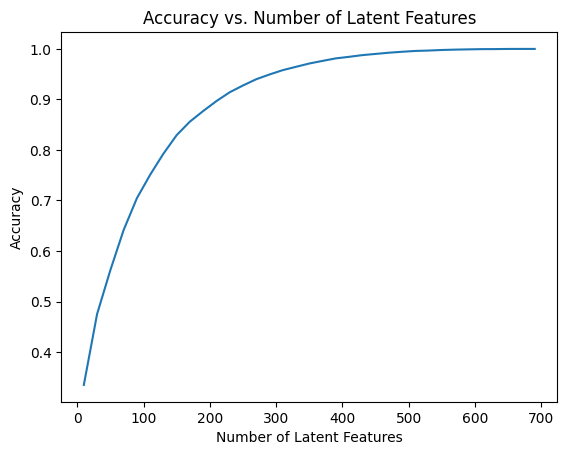

In [42]:
num_latent_feats = np.arange(10,700+10,20)
sum_errs = []

for k in num_latent_feats:
    # restructure with k latent features
    s_new, u_new, vt_new = np.diag(s[:k]), u[:, :k], vt[:k, :]
    
    # take dot product
    user_item_est = np.around(np.dot(np.dot(u_new, s_new), vt_new))
    
    # compute error for each prediction to actual value
    diffs = np.subtract(user_item_matrix, user_item_est)
    
    # total errors and keep track of them
    err = np.sum(np.sum(np.abs(diffs)))
    sum_errs.append(err)
    
    
plt.plot(num_latent_feats, 1 - np.array(sum_errs)/df.shape[0]);
plt.xlabel('Number of Latent Features');
plt.ylabel('Accuracy');
plt.title('Accuracy vs. Number of Latent Features');

## `4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations.  

Instead, we might split our dataset into a training and test set of data, as shown in the cell below.  

Use the code from question 3 to understand the impact on accuracy of the training and test sets of data with different numbers of latent features. Using the split below: 

* How many users can we make predictions for in the test set?  
* How many users are we not able to make predictions for because of the cold start problem?
* How many articles can we make predictions for in the test set?  
* How many articles are we not able to make predictions for because of the cold start problem?

In [43]:
df_train = df.head(40000)
df_test = df.tail(5993)

In [44]:
def create_test_and_train_user_item(df_train, df_test):
    '''
    INPUT:
    df_train - training dataframe
    df_test - test dataframe
    
    OUTPUT:
    user_item_train - a user-item matrix of the training dataframe 
                      (unique users for each row and unique articles for each column)
    user_item_test - a user-item matrix of the testing dataframe 
                    (unique users for each row and unique articles for each column)
    test_idx - all of the test user ids
    test_arts - all of the test article ids
    
    '''
    # Your code here
    user_item_train = create_user_item_matrix(df_train)
    user_item_test = create_user_item_matrix(df_test)

    test_idx = user_item_test.index
    test_arts = df_test["article_id"].unique()
    
    return user_item_train, user_item_test, test_idx, test_arts

user_item_train, user_item_test, test_idx, test_arts = create_test_and_train_user_item(df_train, df_test)

/tmp/ipykernel_5152/3622206896.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  user_item = user_item.applymap(lambda x: 1 if x > 0 else 0)


In [45]:
# Users in train AND in test
len(set(user_item_train.index).intersection(set(user_item_test.index)))

20

In [46]:
# Users not in train but in test
len(user_item_test.index) - 20

662

In [47]:
# Articles in train and in test
len(set(df_train["article_id"].unique()).intersection(set(test_arts)))

574

In [48]:
# Replace the values in the dictionary below
a = 662 
b = 574 
c = 20 
d = 0 


sol_4_dict = {
    'How many users can we make predictions for in the test set?': c, 
    'How many users in the test set are we not able to make predictions for because of the cold start problem?': a, 
    'How many articles can we make predictions for in the test set?': b,
    'How many articles in the test set are we not able to make predictions for because of the cold start problem?': d
}

t.sol_4_test(sol_4_dict)

Awesome job!  That's right!  All of the test articles are in the training data, but there are only 20 test users that were also in the training set.  All of the other users that are in the test set we have no data on.  Therefore, we cannot make predictions for these users using SVD.


## `5.` Now use the **user_item_train** dataset from above to find U, S, and V transpose using SVD. 

Then find the subset of rows in the **user_item_test** dataset that you can predict using this matrix decomposition with different numbers of latent features to see how many features makes sense to keep based on the accuracy on the test data. This will require combining what was done in questions `2` - `4`.

Use the cells below to explore how well SVD works towards making predictions for recommendations on the test data.  

In [49]:
# fit SVD on the user_item_train matrix
u_train, s_train, vt_train = svd(user_item_train)

In [122]:
def compare_train_to_test(user_item_est, user_item_test,user_item_train, test_idx, test_arts):

    user_item_est_df = pd.DataFrame(user_item_est,index=user_item_train.index,columns=user_item_train.columns)

    common_users = list(set(test_idx).intersection(set(user_item_est_df.index)))
    common_articles = list(set(test_arts).intersection(set(user_item_est_df.columns)))

    common_df = user_item_est_df[user_item_est_df.index.isin(common_users)][common_articles]

    diff_matrix = np.zeros((len(common_users), len(common_articles)))

    # Iterate through users and articles
    for i, user in enumerate(common_users):
            for j, article in enumerate(common_articles):
                diff_matrix[i, j] = abs(user_item_est_df.loc[user, article] - user_item_test.loc[user, article])


    return diff_matrix, (common_users,common_articles)

10
30
50
70
90
110
130
150
170
190
210
230
250
270
290
310
330
350
370
390
410
430
450
470
490
510
530
550
570
590
610
630
650
670
690


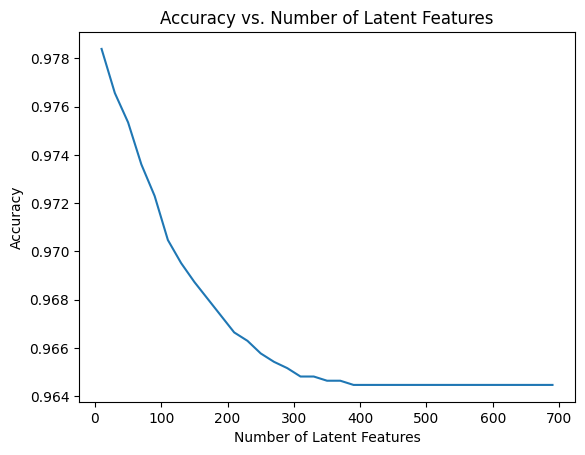

In [123]:
num_latent_feats = np.arange(10,700+10,20)
sum_errs = []

for k in num_latent_feats:
    # restructure with k latent features
    s_new, u_new, vt_new = np.diag(s_train[:k]), u_train[:, :k], vt_train[:k, :]
    
    # take dot product
    user_item_est = np.around(np.dot(np.dot(u_new, s_new), vt_new))
    
    # compute error for each prediction to actual value
    diffs = compare_train_to_test(user_item_est, user_item_test,user_item_train, test_idx, test_arts)
    
    # total errors and keep track of them
    err = np.sum(np.sum(np.abs(diffs[0])))
    sum_errs.append(err)
    
    
accuracy = 1 - np.array(sum_errs) / (diffs[0].shape[0] * diffs[0].shape[1])
plt.plot(num_latent_feats, accuracy);
plt.xlabel('Number of Latent Features');
plt.ylabel('Accuracy');
plt.title('Accuracy vs. Number of Latent Features');